In [1]:
import sys
sys.path.append('../src')
from data_loader import data_stock_loader

In [2]:
df = data_stock_loader()

In [3]:
prophet_df = df.reset_index()[['Date', 'Close']]
prophet_df.columns = ['ds', 'y']
prophet_df.head()

,ds,y
0,2021-08-05,277.851440
1,2021-08-06,277.793823
2,2021-08-09,276.709351
3,2021-08-10,274.895569
4,2021-08-11,275.385010


In [5]:
train_size = int(len(prophet_df) * 0.9)
train_df = prophet_df[:train_size]
test_df = prophet_df[train_size:]

print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")

Train size: 1128, Test size: 126


In [6]:
from prophet import Prophet
model = Prophet()
model.fit(train_df)

Importing plotly failed. Interactive plots will not work.
14:26:54 - cmdstanpy - INFO - Chain [1] start processing
14:26:56 - cmdstanpy - INFO - Chain [1] done processing


In [7]:
future = model.make_future_dataframe(periods=len(test_df))
forecast = model.predict(future)

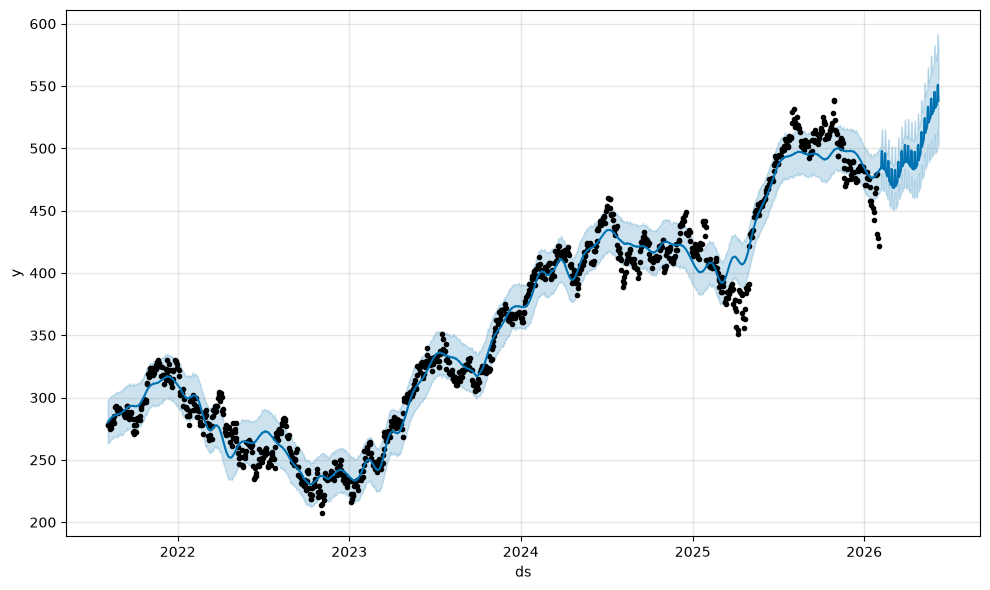

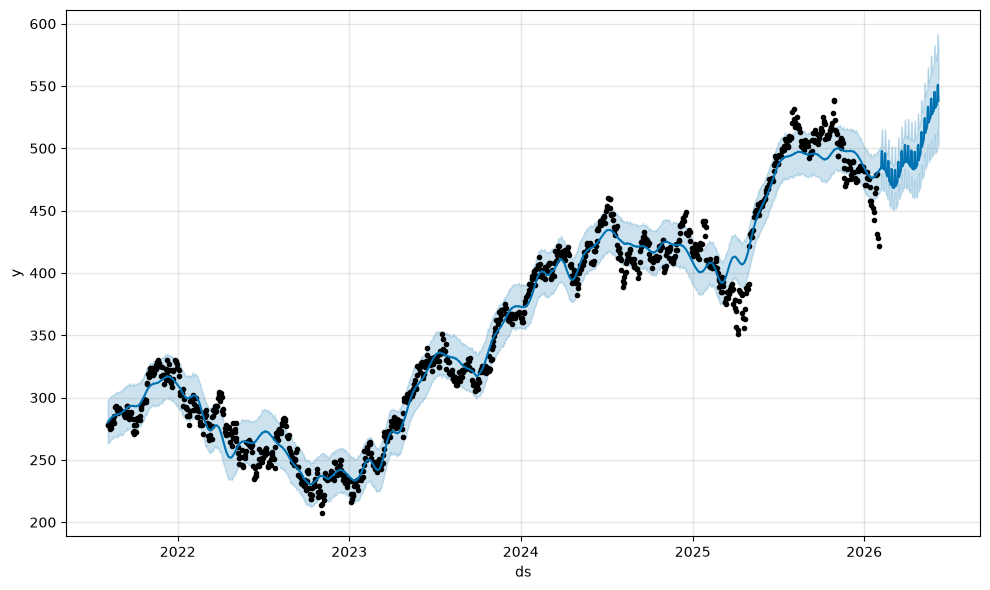

In [8]:
model.plot(forecast)

In [11]:
predicted = forecast['yhat'].iloc[-len(test_df):].values
actual = test_df['y'].values

In [12]:
from utils import calculate_rmse
rmse_prophet = calculate_rmse(actual, predicted)
print("Prophet RMSE:", rmse_prophet)

Prophet RMSE: 101.1961359247235


In [14]:
import joblib, json

# Save the trained model
joblib.dump(model, '../models/prophet_model.pkl')

# Save the forecast results
with open('../models/prophet_results.json', 'w') as f:
    json.dump({"Prophet RMSE": rmse_prophet}, f)